In [2]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import numpy as np
import seaborn as sns
from enum import Enum

In [3]:
df = pd.read_csv("../complex_env_dual_arm_collision_2026-08-05_21-41-59.csv")
df.set_index("file", inplace=True)

class AlgoData:
    class Category(Enum):
        INTERSECTION =  "Intersection"
        DISTANCE = "Distance"

    class Language(Enum):
        CPP = "C++"
        RUST = "Rust"
        PYTHON = "Python"

    def __init__(self, pretty_name: str, language: Language, category: Category):
        self.pretty_name = pretty_name
        self.language = language
        self.category = category

algo_metadata = {
    "FCL distance":                         AlgoData("HPP-FCL", AlgoData.Language.CPP, AlgoData.Category.DISTANCE),
    "FCL intersection":                     AlgoData("HPP-FCL", AlgoData.Language.CPP, AlgoData.Category.INTERSECTION),
    "FCL distance linear support":          AlgoData("HPP-FCL [lin. support]", AlgoData.Language.CPP, AlgoData.Category.DISTANCE),
    "FCL intersection linear support":      AlgoData("HPP-FCL [lin. support]", AlgoData.Language.CPP, AlgoData.Category.INTERSECTION),
    "Jolt intersection":                    AlgoData("Jolt", AlgoData.Language.CPP, AlgoData.Category.INTERSECTION),
    "Jolt distance":                        AlgoData("Jolt", AlgoData.Language.CPP, AlgoData.Category.DISTANCE),
    "libccd intersection":                  AlgoData("libccd", AlgoData.Language.CPP, AlgoData.Category.INTERSECTION),
    "libccd intersection linear support":   AlgoData("libccd [lin. support]", AlgoData.Language.CPP, AlgoData.Category.INTERSECTION),
    "Bullet distance":                      AlgoData("Bullet", AlgoData.Language.CPP, AlgoData.Category.DISTANCE),
    "openGJK distance":                     AlgoData("OpenGJK", AlgoData.Language.CPP, AlgoData.Category.DISTANCE),
    "openGJK distance linear support":      AlgoData("OpenGJK [lin. support]", AlgoData.Language.CPP, AlgoData.Category.DISTANCE),

    "ncollide_distance":            AlgoData("ncollide", AlgoData.Language.RUST, AlgoData.Category.DISTANCE),
    "collision-rs_nasterov_gjk":    AlgoData("collision-rs Nesterov", AlgoData.Language.RUST, AlgoData.Category.DISTANCE),
    "collision-rs_distance_gjk":    AlgoData("collision-rs", AlgoData.Language.RUST, AlgoData.Category.DISTANCE),
    "collision-rs_intersect_gjk":   AlgoData("collision-rs", AlgoData.Language.RUST, AlgoData.Category.INTERSECTION),
    "gjk-rs_nasterov_gjk":          AlgoData("gjk-rs", AlgoData.Language.RUST, AlgoData.Category.DISTANCE),

    "Pybullet":                                 AlgoData("PyBullet", AlgoData.Language.PYTHON, AlgoData.Category.DISTANCE),
    "distance3d Nesterov (with acceleration)":  AlgoData("distance3d Nest. Acc.", AlgoData.Language.PYTHON, AlgoData.Category.DISTANCE),
    "distance3d Nesterov":                      AlgoData("distance3d Nest.", AlgoData.Language.PYTHON, AlgoData.Category.DISTANCE),
    "distance3d Jolt (intersection)":           AlgoData("distance3d Jolt", AlgoData.Language.PYTHON, AlgoData.Category.INTERSECTION),
    "distance3d Jolt (distance)":               AlgoData("distance3d Jolt", AlgoData.Language.PYTHON, AlgoData.Category.DISTANCE),
    "distance3d Original":                      AlgoData("distance3d Orig.", AlgoData.Language.PYTHON, AlgoData.Category.DISTANCE),
}

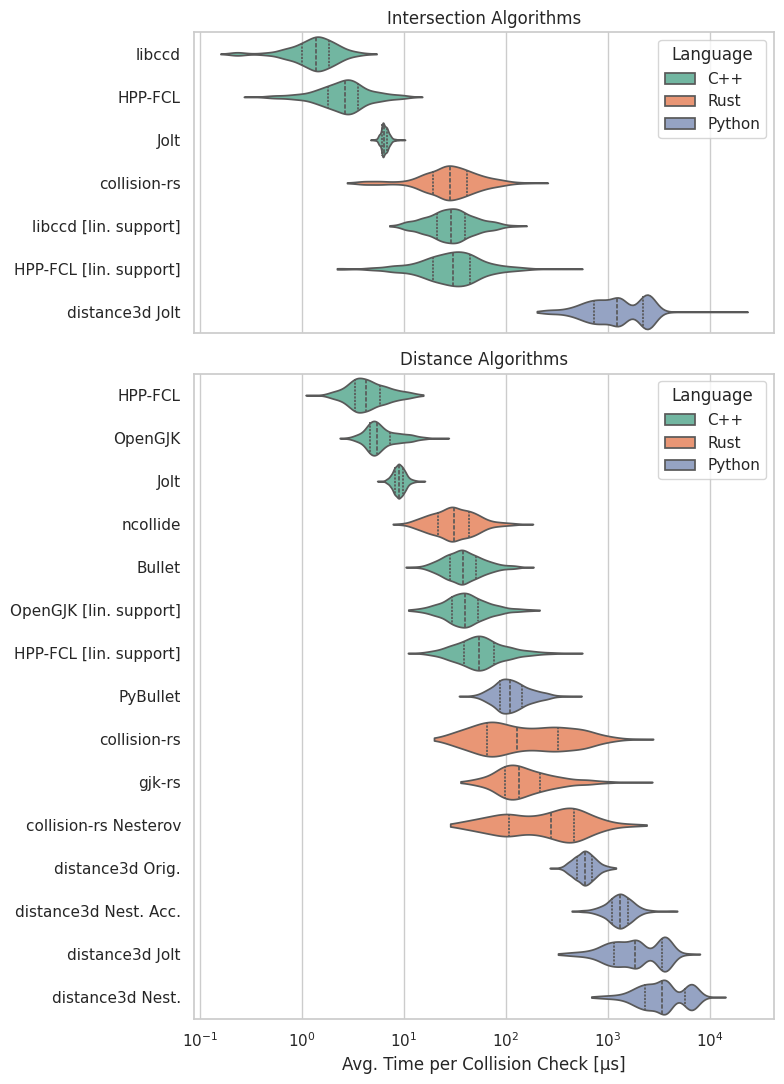

In [4]:
# Violin plot:
sns.set_theme(style="whitegrid")

df_long = df.melt(var_name='Algorithm', value_name='Value')

# Add metadata columns:
df_long['Language'] = df_long['Algorithm'].map(lambda name: algo_metadata[name].language.value)
df_long['Category'] = df_long['Algorithm'].map(lambda name: algo_metadata[name].category)
df_long['PrettyName'] = df_long['Algorithm'].map(lambda name: algo_metadata[name].pretty_name)

languages = [lang.value for lang in AlgoData.Language]
lang_colors = sns.color_palette('Set2', n_colors=len(languages))
lang_palette = dict(zip(languages, lang_colors))

categories = [c for c in AlgoData.Category]

n_algos_per_cat = [
    df_long[df_long['Category'] == c]['Algorithm'].nunique()
    for c in categories
]
row_height = 0.5
subplot_heights = [n * row_height for n in n_algos_per_cat]
fig, axes = plt.subplots(
    nrows=len(categories), ncols=1,
    figsize=(8, sum(subplot_heights)),
    sharex=True,
    gridspec_kw={'height_ratios': n_algos_per_cat}
)

for ax, category in zip(axes, categories):
    df_cat = df_long[df_long['Category'] == category]

    # Order the algorithms by median performance:
    order = (
        df_cat.groupby('PrettyName')['Value']
        .median()
        .sort_values(ascending=True)
        .index.tolist()
    )
    cat_languages = df_cat['Language'].unique().tolist()

    sns.violinplot(
        data=df_cat,
        y='PrettyName', x='Value',
        order=order, hue='Language', hue_order=cat_languages,
        palette=lang_palette,
        inner="quart", density_norm="count", log_scale=True, cut=0,
        ax=ax
    )
    ax.set_title(category.value + " Algorithms")
    ax.set_ylabel("")

axes[-1].set_xlabel("Avg. Time per Collision Check [µs]")
plt.tight_layout()
plt.show()